# Tâche 5

Etudier l’effet de 3 éléments de symétrie différents (pas l’identité) chacun pour 1 atome différent.

In [1]:
import numpy as np
from mp_api.client import MPRester
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from jupyter_jsmol.pymatgen import quick_view
from plotly.subplots import make_subplots
from pymatgen.io.cif import CifWriter
import plotly.graph_objects as go
from IPython.display import Image

In [2]:
mp_key = "xaEW7gxeGjtHSTeJuWSz9Uf8JpzNlgtg"
mp_id = "mp-9382"

In [3]:
with MPRester(mp_key) as m:
    structure = m.get_structure_by_material_id(mp_id)
struct = SpacegroupAnalyzer(structure)
conv_struc = SpacegroupAnalyzer(structure).get_conventional_standard_structure()
symmops = SpacegroupAnalyzer(conv_struc).get_space_group_operations()


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

# 0) Informations préalables

Afin d'étudier les éléments de symétrie, nous choisissons de travailler avec la maille conventionnelle, car celle-ci permet de faire apparaître l’ensemble des opérations de symétrie propres à la structure cristalline.

Nous avons précédemment identifié le groupe ponctuel de la structure comme étant $ \overline{3}m $. Celui-ci indique la présence d’un axe de rotoinversion d’ordre 3, c’est-à-dire une rotation d’ordre 3 suivie d’une inversion, ainsi que de plans miroirs perpendiculaires à cet axe.

Nous travaillons ici avec la maille conventionnelle qui est hexagonale. Dans ce cas, l’axe c (d’ordre 4, 3, et 6) est unique, et le 1er symbole du groupe ponctuel reflète la symétrie le long de cet axe. 

Dans ce cadre :

- Le deuxième symbole du groupe ponctuel indique la symétrie le long des directions :
  $
  [100],\ [010],\ [1\bar{1}0]
  $

- Le troisième symbole représente la symétrie le long des directions :
  $
  [110],\ [120],\ [2\bar{1}0]
  $

Nous étudions ici trois éléments de symétrie distincts, chacun appliqué à un atome différent. Les atomes sélectionnés pour cette analyse sont présentés ci-dessous

In [4]:
sites = conv_struc.sites  
Sr_atom = 1
Zr_atom = 4
N_atom = 8

# 1) Première opération de symétrie

Pour cette première opération de symétrie, nous nous concentrons sur un atome de strontium (Sr).  Il s'agit d'une inversion, c’est-à-dire une opération de symétrie de deuxième espèce qui inverse la chiralité.

La transformation appliquée aux coordonnées cartésiennes $(x, y, z)$ s’exprime comme suit :

$$
(x, y, z) \longrightarrow (-x, -y, -z)
$$

### Matrice de l'opération

$$
\begin{bmatrix}
-1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{bmatrix}
$$


### Vecteur de translation

$$
\tau =
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
$$

Cette opération est également symmorphique, car elle ne comporte aucune composante de translation.  En effet, le vecteur de translation $\tau$ est nul, ce qui signifie que cette opération est une inversion pure, sans déplacement additionnel du motif cristallin.





In [5]:
i_atom = Sr_atom
i_symmop = 2

symmop = symmops[i_symmop - 1]
print(symmop)

Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]


In [6]:
pos_init = conv_struc.sites[i_atom - 1].frac_coords
pos_final = symmop.operate(pos_init)


print(f"Atome {i_atom} :")
print(f"Position initiale : {pos_init}")
print(f"Position après symétrie : {pos_final}\n")


Atome 1 :
Position initiale : [0. 0. 0.]
Position après symétrie : [0. 0. 0.]



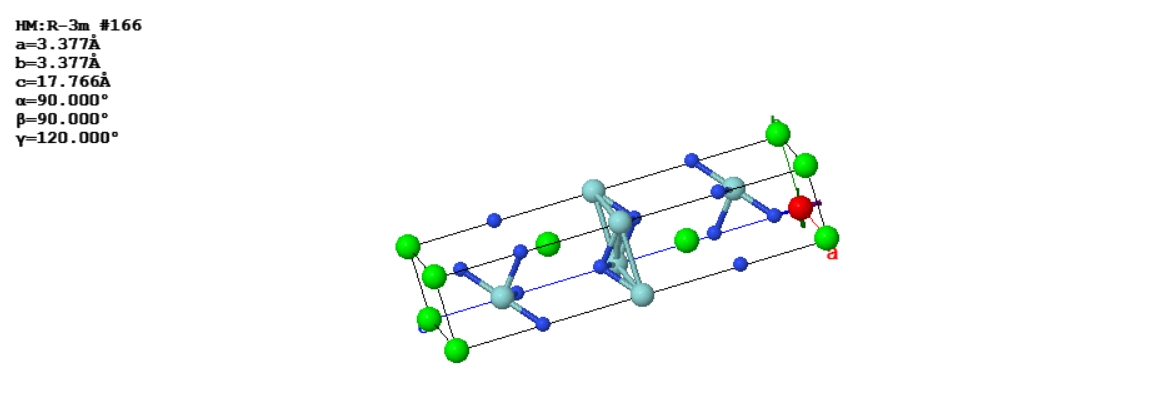

In [7]:
display(Image(filename="Op1.png"))

# 2) Deuxième opération de symétrie

Pour la deuxième opération de symétrie, nous nous concentrons sur un atome de zirconium (Zr).  Il s'agit d'une rotation d'ordre 3 autour de l'axe $ z $, caractéristique des systèmes cristallins trigonaux.  

La transformation appliquée aux coordonnées cartésiennes $(x, y, z)$ peut être décrite par :

$$
(x, y, z) \longrightarrow (-y, x - y, z)
$$

### Matrice de l'opération

$$
\begin{bmatrix}
0 & -1 & 0 \\
1 & -1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Cette matrice correspond à une rotation de 120° dans le plan $(a, b)$, autour de l'axe $ z $, tout en conservant la coordonnée $ z $ inchangée. Son déterminant vaut 1, ce qui indique qu'il s'agit d'une opération de première espèce qui conserve la chiralité.

### Vecteur de translation

$$
\tau =
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
$$

Cette opération est dite symmorphique, car elle ne comporte aucune composante de translation. En effet, le vecteur de translation $ 	au $ est nul, ce qui signifie que cette opération de symétrie est une pure rotation, sans déplacement du motif cristallin.


In [8]:
i_atom = Zr_atom
i_symmop = 3


symmop = symmops[i_symmop - 1]


print(f"Numéro de l'opération de symétrie : {i_symmop}")
print(f"Atome sélectionné : {i_atom}\n")

print("Détails de l'opération :")

print(symmop)


Numéro de l'opération de symétrie : 3
Atome sélectionné : 4

Détails de l'opération :
Rot:
[[ 0. -1.  0.]
 [ 1. -1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]


In [9]:
pos_init = conv_struc.sites[i_atom - 1].frac_coords
pos_final = symmop.operate(pos_init)


print(f"Atome {i_atom} :")
print(f"Position initiale : {pos_init}")
print(f"Position après symétrie : {pos_final}\n")

Atome 4 :
Position initiale : [0.66666667 0.33333333 0.83333333]
Position après symétrie : [-0.33333333  0.33333333  0.83333333]



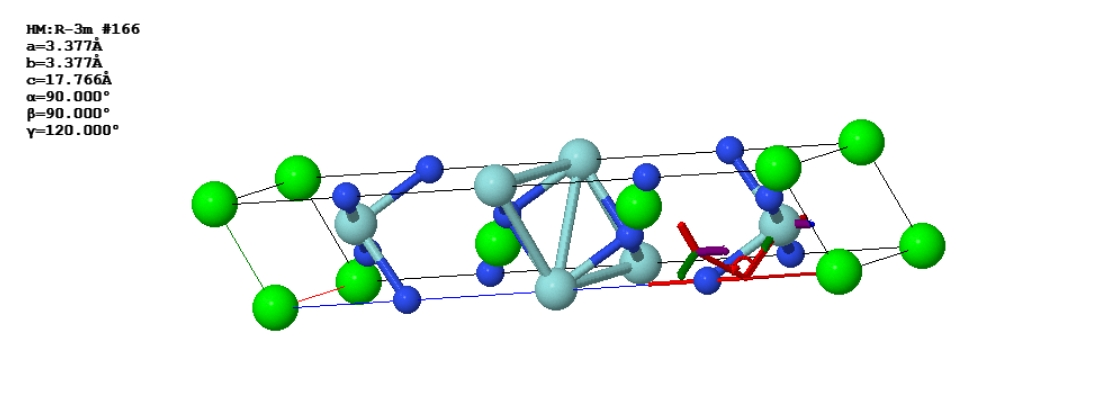

In [10]:
display(Image(filename="OP2.png"))

# 3) Troisième opération de symétrie

Pour cette troisième opération de symétrie, nous nous concentrons sur un atome d’azote (N). Cette opération correspond à une réflexion par rapport à un plan incliné, qui affecte uniquement la coordonnée $ x $ tandis que les coordonnées $ y $ et $ z$ restent inchangées.  

La transformation appliquée peut s’écrire :

$$
(x, y, z) \longrightarrow (-x + y,\ y,\ z)
$$

Cette opération est de deuxième espèce, car elle inverse la chiralité du système. Cela est confirmé par le déterminant négatif de la matrice de rotation, qui vaut $-1$.

### Matrice de l'opération

$$
\begin{bmatrix}
-1 & 1 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Cette matrice indique une réflexion partielle dans le plan $(x, y)$, laissant $ y $ et $ z $ inchangés tout en modifiant $ x $.

### Vecteur de translation

$$
\tau =
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
$$

L’opération est symmorphique, car elle ne comporte aucune composante de translation.  En effet, le vecteur de translation $\tau$ est nul, ce qui signifie qu’il s’agit d’une réflexion pure, sans déplacement additionnel du motif cristallin.


In [11]:
i_atom = N_atom
i_symmop = 10


symmop = symmops[i_symmop - 1]


print(f"Numéro de l'opération de symétrie : {i_symmop}")
print(f"Atome sélectionné : {i_atom}\n")

print("Détails de l'opération :")

print(symmop)

Numéro de l'opération de symétrie : 10
Atome sélectionné : 8

Détails de l'opération :
Rot:
[[-1.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]


In [12]:
pos_init = conv_struc.sites[i_atom -1].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome {i_atom} :")
print(f"Position initiale : {pos_init}")
print(f"Position après symétrie : {pos_final}\n")


Atome 8 :
Position initiale : [0.33333333 0.66666667 0.90007631]
Position après symétrie : [0.33333333 0.66666667 0.90007631]



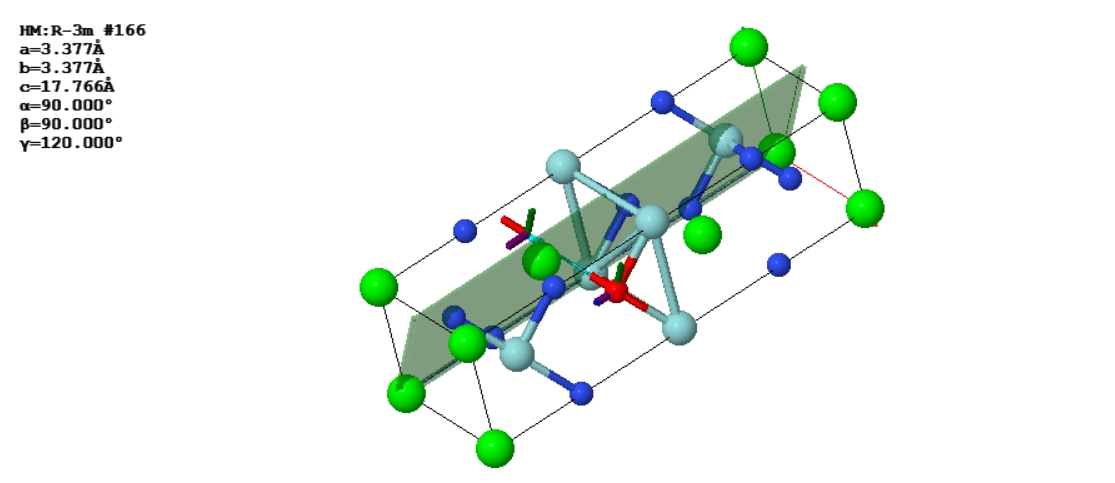

In [13]:
display(Image(filename="Op3.png"))

# 4) Informations complémentaires

Pour identifier les opérations de symétrie pertinentes à analyser, l’ensemble des opérations de symétrie de la structure a été examiné.

In [14]:
print(f"Nombre total d'opérations de symétrie : {len(symmops)}\n")
for i_symmop in range(1, len(symmops) + 1):
    symmop = symmops[i_symmop - 1]
    print(f"Opération {i_symmop} :")
    print(symmop) 
    print()


Nombre total d'opérations de symétrie : 36

Opération 1 :
Rot:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
tau
[0. 0. 0.]

Opération 2 :
Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 3 :
Rot:
[[ 0. -1.  0.]
 [ 1. -1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]

Opération 4 :
Rot:
[[ 0.  1.  0.]
 [-1.  1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 5 :
Rot:
[[-1.  1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]

Opération 6 :
Rot:
[[ 1. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 7 :
Rot:
[[ 0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 8 :
Rot:
[[ 0. -1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]

Opération 9 :
Rot:
[[ 1. -1.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 10 :
Rot:
[[-1.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]

Opération 11 :
Rot:
[[-1.  0.  0.]
 [-1.  1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]

Opération 12 :
Rot:
[[ 1.  0.  0.]
 [ 1. -1.  0.]
 [ 0.  0.  1.]]
tau
[0

Nous avons ensuite sélectionné les atomes sur lesquels nous allions nous concentrer.

In [15]:
sga_conv = SpacegroupAnalyzer(conv_struc)
symm_struct = sga_conv.get_symmetrized_structure()

print("Sites par type d’atome\n")

for group in symm_struct.equivalent_sites:
    site_type = group[0].species_string
    print(f"-Atome : {site_type}")
    
    for s in group:
        # Trouver l'index du site dans conv_struc.sites
        for i, site in enumerate(conv_struc.sites):
            if site == s:
                index = i
                break
        print(f"Index : {index} , Position fractionnaire : {s.frac_coords}")
    print()


sites = conv_struc.sites
Sr_sites = [s for s in sites if s.species_string == "Sr"]
Zr_sites = [s for s in sites if s.species_string == "Zr"]
N_sites  = [s for s in sites if s.species_string == "N"]

print("Résumé des atomes dans la maille conventionnelle ")
print(f"Nombre d'atomes Sr : {len(Sr_sites)}")
print(f"Nombre d'atomes Zr : {len(Zr_sites)}")
print(f"Nombre d'atomes N  : {len(N_sites)}")

Sites par type d’atome

-Atome : Sr
Index : 0 , Position fractionnaire : [0. 0. 0.]
Index : 1 , Position fractionnaire : [0.66666667 0.33333333 0.33333333]
Index : 2 , Position fractionnaire : [0.33333333 0.66666667 0.66666667]

-Atome : Zr
Index : 3 , Position fractionnaire : [0.66666667 0.33333333 0.83333333]
Index : 4 , Position fractionnaire : [0.33333333 0.66666667 0.16666667]
Index : 5 , Position fractionnaire : [1.  1.  0.5]

-Atome : N
Index : 6 , Position fractionnaire : [0.         0.         0.76659036]
Index : 7 , Position fractionnaire : [0.33333333 0.66666667 0.90007631]
Index : 8 , Position fractionnaire : [0.66666667 0.33333333 0.09992369]
Index : 9 , Position fractionnaire : [0.         0.         0.23340964]
Index : 10 , Position fractionnaire : [0.33333333 0.66666667 0.43325703]
Index : 11 , Position fractionnaire : [0.66666667 0.33333333 0.56674297]

Résumé des atomes dans la maille conventionnelle 
Nombre d'atomes Sr : 3
Nombre d'atomes Zr : 3
Nombre d'atomes N  : 

Pour la visualisation des opérations nous avons utilisé le code suivant : 

In [16]:
view = quick_view(conv_struc, "packed", conventional=True)
display(view)

JsmolView(layout=Layout(align_self='stretch', height='400px'))

In [17]:
view.script('background white; draw SYMOP ' + str(i_symmop) + ' {atomno = ' + str(i_atom) + '}')